# IMPORT STATEMENTS

In [1]:
import os
import json
import copy
import time
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms, models
from tqdm.notebook import tqdm, trange
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# PATHS AND VARIABLES

In [2]:
DATA_DIR = "../data/combined-dataset-16class"
WEIGHTS_PATH = f"{DATA_DIR}/class_weights.json"
BATCH_SIZE = 64
NUM_CLASSES = 16
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
APPLY_NOISE = False 
MODEL_NAME = "resnet_50"

In [3]:
os.makedirs("../visualizations", exist_ok=True)
os.makedirs(f"../visualizations/{MODEL_NAME}", exist_ok=True)

# SET DEVICE

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


# GAUSSIAN NOISE

In [5]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# DEFINE TRANSFORMS

In [5]:
train_transform_list = [
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

In [6]:
if APPLY_NOISE:
    train_transform_list.append(AddGaussianNoise(mean=0.0, std=0.05))
train_transform = transforms.Compose(train_transform_list)

In [7]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# CREATE DATALOADERS

In [8]:
train_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=eval_transform)

In [9]:
validation_split = 0.2
dataset_size = len(train_dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))

In [10]:
np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

In [11]:
train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)

In [13]:
class_names = train_dataset.classes
print(f"Total training directory images: {dataset_size}")
print(f"Dynamically split into -> Train: {len(train_indices)} | Validation: {len(val_indices)}")

Total training directory images: 2459
Dynamically split into -> Train: 1968 | Validation: 491


# LOAD PRETRAINED ResNet-50

In [14]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Modify the final layer (ResNet uses 'fc')
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)
print("ResNet50 initialized and moved to GPU.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jagujay/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:12<00:00, 8.29MB/s]


ResNet50 initialized and moved to GPU.


# INITIALIZE WEIGHTS

In [15]:
with open(WEIGHTS_PATH, "r") as f:
    weight_dict = json.load(f)

weights_list = [weight_dict[c] for c in class_names]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float32).to(device)

In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# SET DROPOUT FEATURES

In [17]:
patience = 5
best_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

In [18]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# TRAINING LOOP

In [19]:
start_time = time.time()

epoch_pbar = trange(NUM_EPOCHS, desc="Overall Progress", unit="epoch")

for epoch in epoch_pbar:
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        batch_pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [{phase.capitalize()}]", leave=False)

        for inputs, labels in batch_pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            batch_pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

        # Calculate epoch-level metrics
        dataset_size = len(dataloader.sampler)
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())
            
            tqdm.write(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                       f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
                       f"Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

    if patience_counter >= patience:
        tqdm.write(f"Early stopping triggered at epoch {epoch+1}!")
        break

time_elapsed = time.time() - start_time
print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

Overall Progress:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 2.6314 Acc: 0.1596 | Val Loss: 3.1650 Acc: 0.1426


Epoch 2 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 27 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 27/30 | Train Loss: 1.0965 Acc: 0.5884 | Val Loss: 1.6116 Acc: 0.4827


Epoch 28 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 28 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 28/30 | Train Loss: 1.0425 Acc: 0.5884 | Val Loss: 1.4234 Acc: 0.5051
Early stopping triggered at epoch 28!

Training complete in 134m 5s


# SAVE BEST MODEL WEIGHTS

In [20]:
model.load_state_dict(best_model_wts)
os.makedirs("../models", exist_ok=True)
os.makedirs(f"../models/{MODEL_NAME}", exist_ok=True)
torch.save(model.state_dict(), f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth")
print(f"Best model saved to ../models/{MODEL_NAME}/{MODEL_NAME}_best.pth")

Best model saved to ../models/resnet_50/resnet_50_best.pth


# TESTING

In [6]:
MODEL_WEIGHTS_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth"

print(f"Evaluating on device: {device}")
sns.set_theme(style="whitegrid")

Evaluating on device: cuda


# DEFINE TRANSFORM

In [7]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# CREATE DATALOADER

In [8]:
test_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [9]:
class_names = test_dataset.classes
print(f"Loaded {len(test_dataset)} test images across {len(class_names)} classes.")

Loaded 322 test images across 16 classes.


# LOAD MODEL WEIGHTS

In [10]:
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
model = model.to(device)
model.eval()
print(f"Successfully loaded {MODEL_NAME} weights from disk.")

/tmp/ipykernel_6933/1979329458.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))


Successfully loaded resnet_50 weights from disk.


In [11]:
all_labels = []
all_probs = []
all_preds = []

# GENERATE PREDICTIONS

In [12]:
print("Generating predictions...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Generating predictions...


# CLASSIFICATION REPORT

In [13]:
print(f"CLASSIFICATION REPORT: {MODEL_NAME.upper()}")
report_text = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report_text)

CLASSIFICATION REPORT: RESNET_50
                            precision    recall  f1-score   support

                Apple Leaf     0.7273    0.8000    0.7619        20
           Apple Rust Leaf     0.8800    0.6875    0.7719        32
           Apple Scab leaf     0.6429    0.2812    0.3913        32
       Corn Gray Leaf Spot     0.4615    0.8000    0.5854        15
                 Corn Leaf     0.7143    0.9091    0.8000        11
          Corn Leaf Blight     0.8462    0.4783    0.6111        23
            Corn Rust Leaf     0.8182    0.8571    0.8372        21
        Potato Leaf Blight     0.6667    0.3704    0.4762        27
     Potato Leafroll Virus     0.4706    0.7273    0.5714        11
               Tomato Leaf     0.7647    0.6842    0.7222        19
Tomato Leaf Bacterial Spot     0.3158    0.3000    0.3077        20
  Tomato Leaf Early Blight     0.3143    0.5500    0.4000        20
   Tomato Leaf Late Blight     0.4444    0.3810    0.4103        21
Tomato Leaf Po

In [14]:
with open(f"../visualizations/{MODEL_NAME}/report.txt", "w") as f:
    f.write(f"Classification Report for {MODEL_NAME.upper()}\n\n")
    f.write(report_text)

In [15]:
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(f"../visualizations/{MODEL_NAME}/report.csv")
print(f"Metrics saved to ../visualizations/{MODEL_NAME}/report.csv")

Metrics saved to ../visualizations/resnet_50/report.csv


# CONFUSION MATRIX

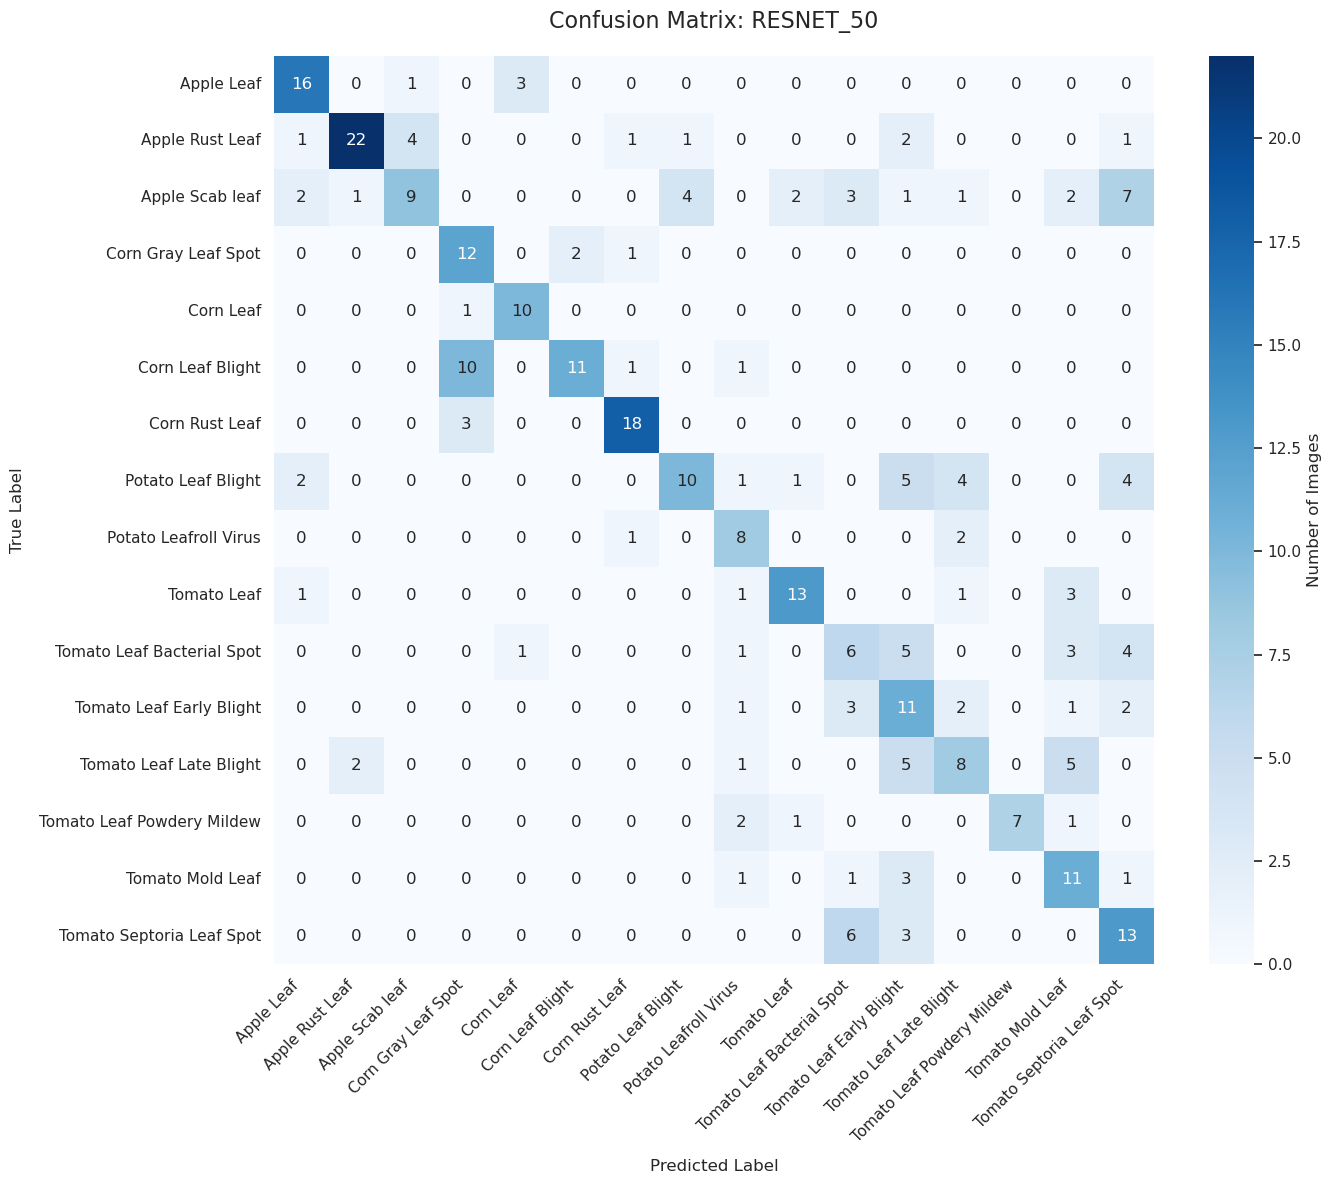

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Number of Images'})
plt.title(f'Confusion Matrix: {MODEL_NAME.upper()}', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../visualizations/{MODEL_NAME}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# AUC ROC CURVE

In [17]:
n_classes = len(class_names)
y_bin = label_binarize(all_labels, classes=range(n_classes))
all_probs = np.array(all_probs)

In [18]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

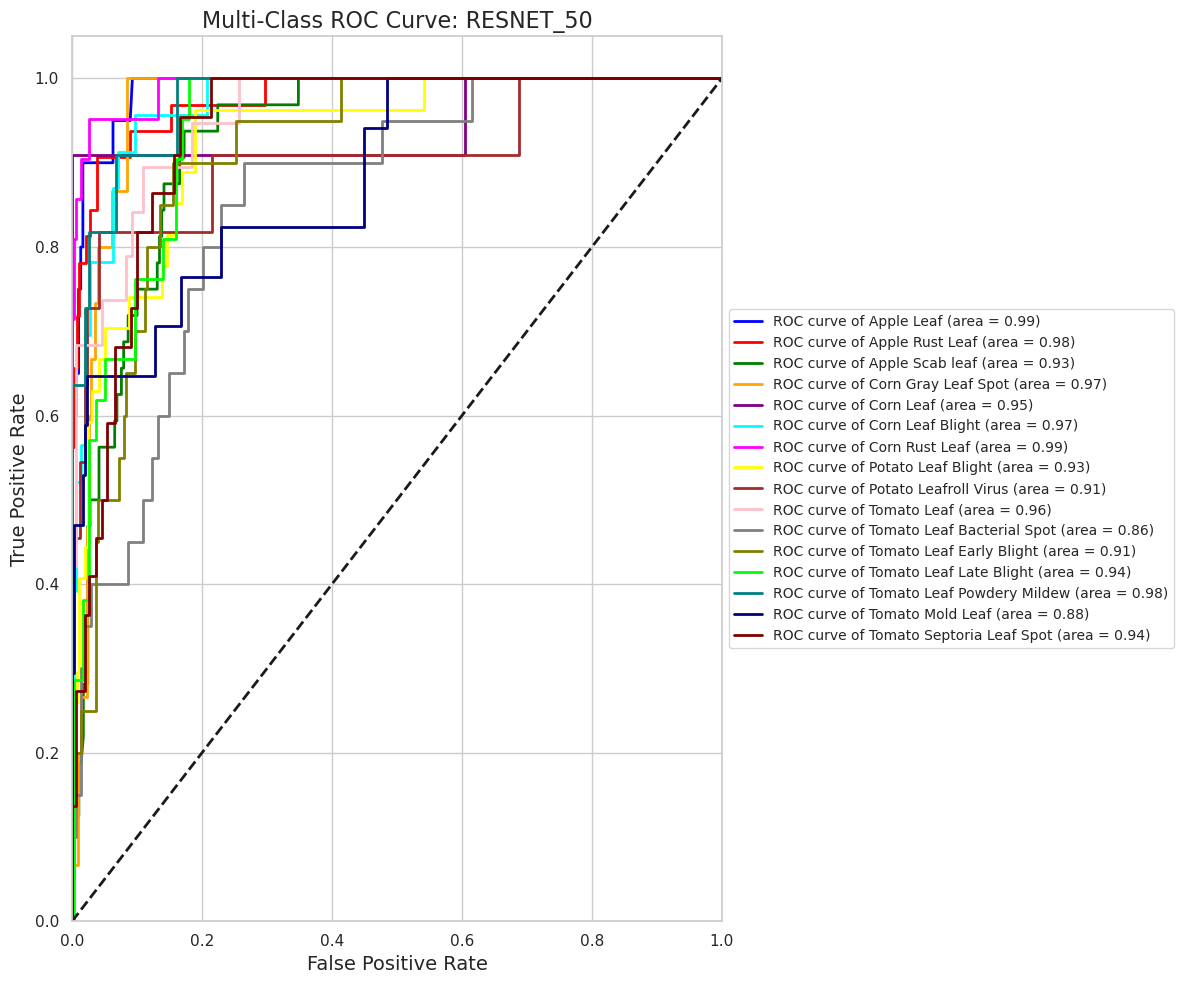

In [19]:
plt.figure(figsize=(12, 10))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink', 'gray', 'olive', 'lime', 'teal', 'navy', 'maroon'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title(f'Multi-Class ROC Curve: {MODEL_NAME.upper()}', fontsize=16)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.savefig(f"../visualizations/{MODEL_NAME}/{MODEL_NAME}_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()